In [1]:
import sys
from pathlib import Path
import warnings

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import (PROJECT_ROOT, 
                        GRAPHS_DIR, 
                        DATA_PATHS, 
                        BIZ, CON, BIZ_ALPHA, CON_ALPHA, 
                        MC_DARK, MC_LIGHT, MC_GRAY, 
                        PLT_PARAMS, 
                        mc_title, mc_legend)
from src.data import load_data
from src.features import mcc_range_segment

import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap as _LSC
plt.rcParams.update(PLT_PARAMS)
_CM_CMAP = _LSC.from_list('mc_cm', [MC_LIGHT, BIZ])

In [3]:
business, consumer, merchants = load_data(DATA_PATHS)

In [4]:
for df in [business, consumer]:
    df['transaction_date']      = pd.to_datetime(df['transaction_date'])
    df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])
    df['mcc']                   = df['mcc'].astype(str).str.strip()
    df['hour']                  = df['transaction_timestamp'].dt.hour
    df['weekday']               = df['transaction_timestamp'].dt.dayofweek  # 0=Mon
    df['is_night']              = ~df['hour'].between(6, 21)

print(f'Business  {len(business):>10,} tx  |  {business["card_number"].nunique():,} cards')
print(f'Consumer  {len(consumer):>10,} tx  |  {consumer["card_number"].nunique():,} cards')
print(f'Window    {business["transaction_date"].min().date()}  →  {business["transaction_date"].max().date()}')

Business   2,997,593 tx  |  25,000 cards
Consumer   9,832,487 tx  |  80,000 cards
Window    2025-10-01  →  2026-03-31


# Transaction Amount

**Business cards spend 3× more per transaction.** The median is even more telling than the mean — it sits at 77k KZT for business vs 12k KZT for consumer, meaning the gap isn't driven by a few outliers. The distributions barely overlap beyond the 75th percentile.

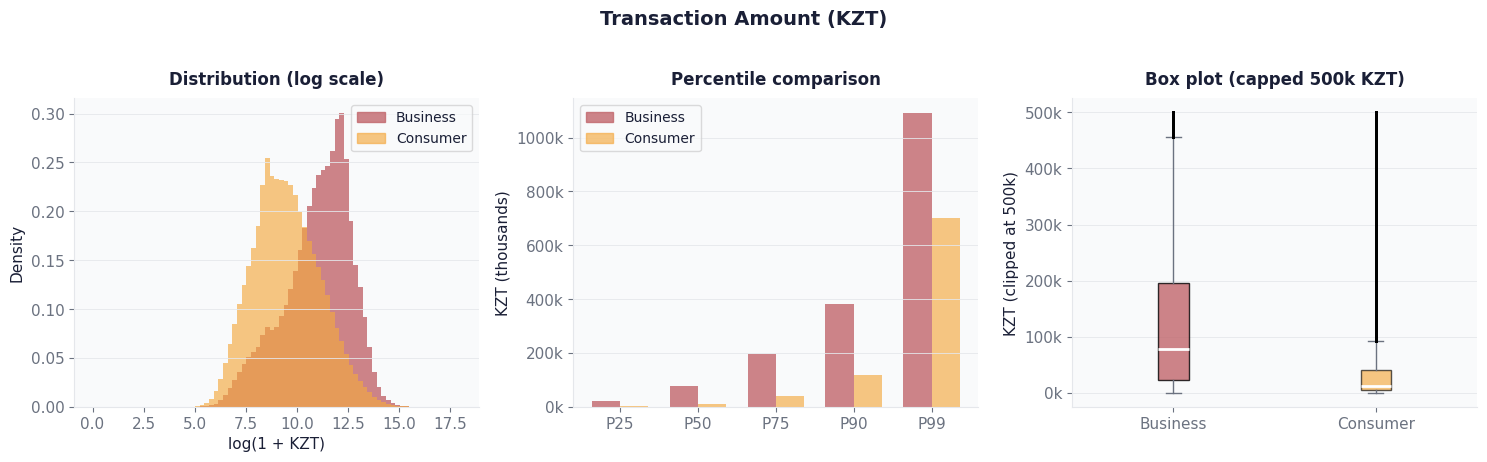

Business median:     77,224 KZT
Consumer median:     11,892 KZT
Ratio          : 6.5x


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Transaction Amount (KZT)', fontsize=14, fontweight='700', color=MC_DARK, y=1.02)

# 1. Log-scale overlapping histograms
ax = axes[0]
bins = np.linspace(0, 18, 80)
ax.hist(np.log1p(business['transaction_amount_kzt']), bins=bins,
        density=True, alpha=BIZ_ALPHA, color=BIZ, label='Business')
ax.hist(np.log1p(consumer['transaction_amount_kzt']), bins=bins,
        density=True, alpha=CON_ALPHA, color=CON, label='Consumer')
ax.set_xlabel('log(1 + KZT)')
ax.set_ylabel('Density')
mc_title(ax, 'Distribution (log scale)')
mc_legend(ax)
ax.grid(True, axis='y')

# 2. Percentile comparison
ax = axes[1]
pcts = [25, 50, 75, 90, 99]
bv = np.percentile(business['transaction_amount_kzt'], pcts)
cv = np.percentile(consumer['transaction_amount_kzt'], pcts)
x  = np.arange(len(pcts))
w  = 0.36
ax.bar(x - w/2, bv/1000, w, color=BIZ, alpha=BIZ_ALPHA)
ax.bar(x + w/2, cv/1000, w, color=CON, alpha=CON_ALPHA)
ax.set_xticks(x)
ax.set_xticklabels([f'P{p}' for p in pcts])
ax.set_ylabel('KZT (thousands)')
mc_title(ax, 'Percentile comparison')
mc_legend(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))
ax.grid(True, axis='y')

# 3. Box plot
ax = axes[2]
clip = 500_000
bp = ax.boxplot(
    [business['transaction_amount_kzt'].clip(upper=clip),
     consumer['transaction_amount_kzt'].clip(upper=clip)],
    labels=['Business', 'Consumer'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color=MC_GRAY),
    capprops=dict(color=MC_GRAY),
    flierprops=dict(marker='.', color=MC_GRAY, markersize=2, alpha=0.3),
)
bp['boxes'][0].set_facecolor(BIZ); bp['boxes'][0].set_alpha(BIZ_ALPHA)
bp['boxes'][1].set_facecolor(CON); bp['boxes'][1].set_alpha(CON_ALPHA)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.set_ylabel('KZT (clipped at 500k)')
mc_title(ax, 'Box plot (capped 500k KZT)')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'fig_amount.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Business median: {business["transaction_amount_kzt"].median():>10,.0f} KZT')
print(f'Consumer median: {consumer["transaction_amount_kzt"].median():>10,.0f} KZT')
print(f'Ratio          : {business["transaction_amount_kzt"].median()/consumer["transaction_amount_kzt"].median():.1f}x')

# Hour of Day - Day vs Night

**Business cards have a double-peak pattern: 10–11am and 14–16pm**, mirroring typical office payment batches. The nights (00–05) maintain a *flat, elevated baseline* — these are automated recurring charges (SaaS subscriptions, ad platforms) firing at midnight UTC regardless of local time. Consumer cards peak in the **evening (17–20)**, reflecting post-work spending, and have genuine quiet nights.

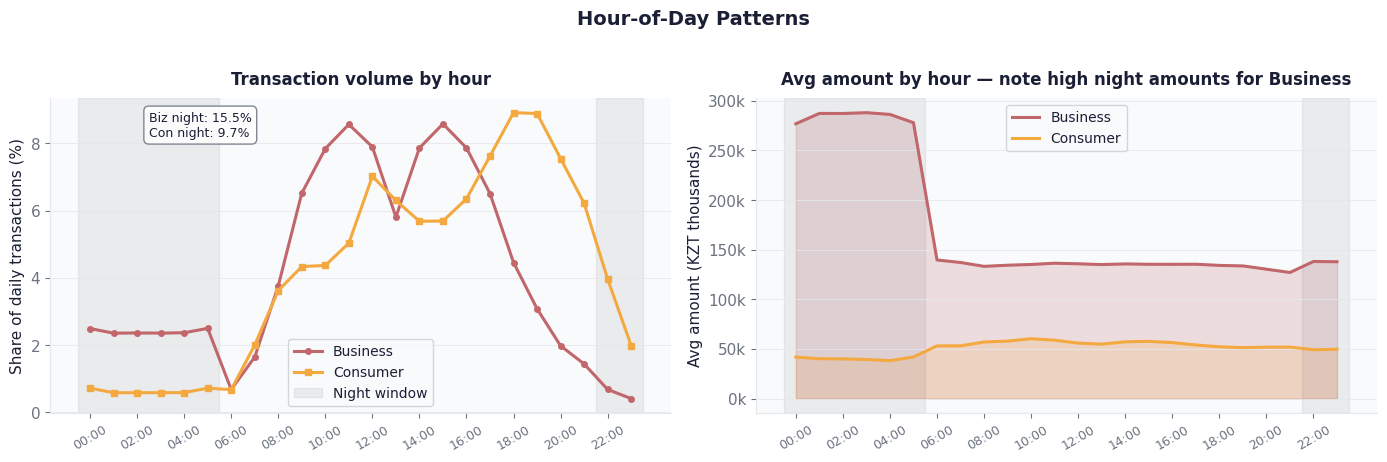

Business night tx share: 15.5%  (00–05 + 22–23)
Consumer night tx share: 9.7%

Business avg amount at midnight (00–05): 283,860 KZT
Consumer avg amount at midnight (00–05): 40,376 KZT


In [6]:
biz_hr  = business['hour'].value_counts(normalize=True).sort_index() * 100
con_hr  = consumer['hour'].value_counts(normalize=True).sort_index() * 100
biz_amt = business.groupby('hour')['transaction_amount_kzt'].mean() / 1000
con_amt = consumer.groupby('hour')['transaction_amount_kzt'].mean() / 1000

biz_night_pct = business['is_night'].mean() * 100
con_night_pct = consumer['is_night'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Hour-of-Day Patterns', fontsize=14, fontweight='700', color=MC_DARK, y=1.02)

hrs = np.arange(24)

ax = axes[0]
ax.plot(hrs, biz_hr.values, color=BIZ, linewidth=2.2, marker='o', markersize=4, label='Business')
ax.plot(hrs, con_hr.values, color=CON, linewidth=2.2, marker='s', markersize=4, label='Consumer')
ax.axvspan(-0.5, 5.5,  alpha=0.08, color='#334155', label='Night window')
ax.axvspan(21.5, 23.5, alpha=0.08, color='#334155')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], fontsize=9, rotation=30)
ax.set_ylabel('Share of daily transactions (%)')
mc_title(ax, 'Transaction volume by hour')
ax.legend(fontsize=10)
ax.grid(True, axis='y')
ax.text(2.5, ax.get_ylim()[1]*0.88,
        f'Biz night: {biz_night_pct:.1f}%\nCon night: {con_night_pct:.1f}%',
        fontsize=9, color=MC_DARK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=MC_GRAY, alpha=0.85))

ax = axes[1]
ax.fill_between(hrs, biz_amt.values, alpha=0.20, color=BIZ)
ax.fill_between(hrs, con_amt.values, alpha=0.18, color=CON)
ax.plot(hrs, biz_amt.values, color=BIZ, linewidth=2.2, label='Business')
ax.plot(hrs, con_amt.values, color=CON, linewidth=2.2, label='Consumer')
ax.axvspan(-0.5, 5.5,  alpha=0.08, color='#334155')
ax.axvspan(21.5, 23.5, alpha=0.08, color='#334155')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], fontsize=9, rotation=30)
ax.set_ylabel('Avg amount (KZT thousands)')
mc_title(ax, 'Avg amount by hour — note high night amounts for Business')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))
ax.legend(fontsize=10)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'fig_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Business night tx share: {biz_night_pct:.1f}%  (00–05 + 22–23)')
print(f'Consumer night tx share: {con_night_pct:.1f}%')
print(f'\nBusiness avg amount at midnight (00–05): {business[business["hour"]<6]["transaction_amount_kzt"].mean():,.0f} KZT')
print(f'Consumer avg amount at midnight (00–05): {consumer[consumer["hour"]<6]["transaction_amount_kzt"].mean():,.0f} KZT')

# MCC Categories


**The clearest structural difference.** Business cards are dominated by B2B categories: IT/SaaS, advertising, subscriptions, and business services together account for **42%** of transactions. Consumer cards are fragmented across everyday life — restaurants, gas stations, taxis, grocery, transit — with almost **50% of transactions in catch-all 'Other' MCCs**, showing the breadth of personal spending.

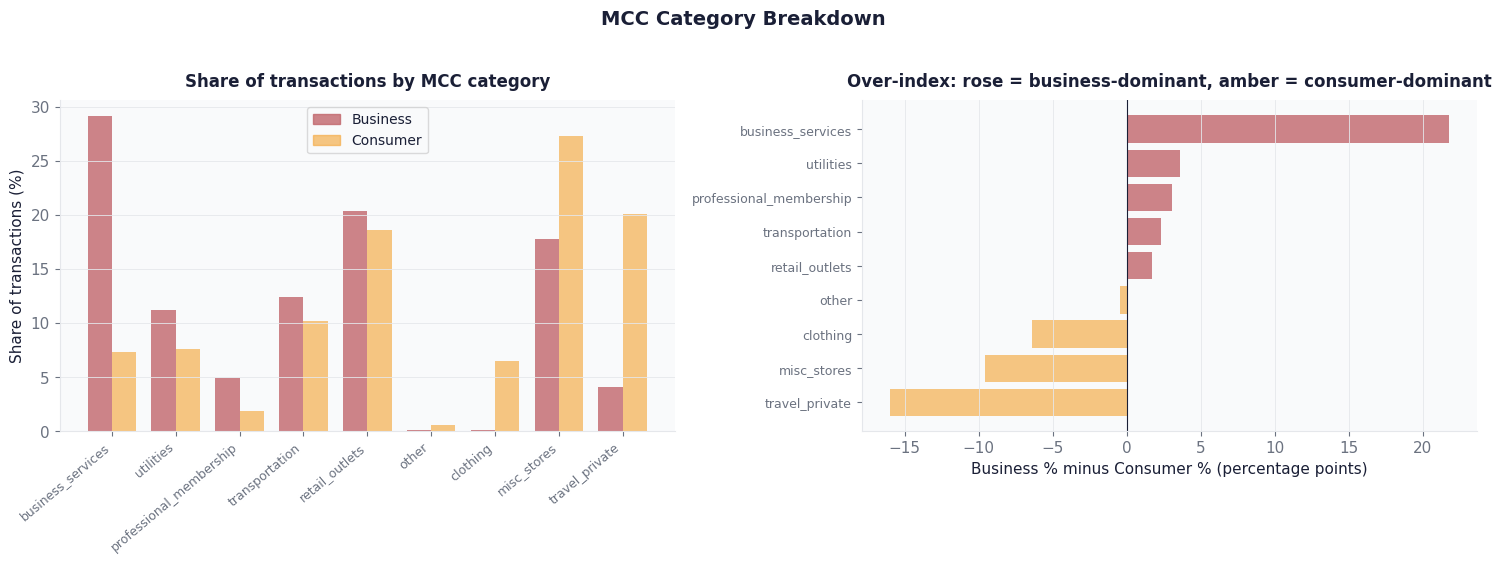

In [7]:
business['mcc_cat'] = business['mcc'].apply(mcc_range_segment)
consumer['mcc_cat'] = consumer['mcc'].apply(mcc_range_segment)

biz_mcc = (business['mcc_cat'].value_counts(normalize=True) * 100)
con_mcc = (consumer['mcc_cat'].value_counts(normalize=True) * 100)
cats    = biz_mcc.index.union(con_mcc.index)
biz_v   = biz_mcc.reindex(cats, fill_value=0)
con_v   = con_mcc.reindex(cats, fill_value=0)
order   = (biz_v - con_v).sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('MCC Category Breakdown', fontsize=14, fontweight='700', color=MC_DARK, y=1.02)

ax = axes[0]
x = np.arange(len(order))
w = 0.38
ax.bar(x - w/2, biz_v[order].values, w, color=BIZ, alpha=BIZ_ALPHA)
ax.bar(x + w/2, con_v[order].values, w, color=CON, alpha=CON_ALPHA)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Share of transactions (%)')
mc_title(ax, 'Share of transactions by MCC category')
mc_legend(ax)
ax.grid(True, axis='y')

ax = axes[1]
diff = (biz_v[order] - con_v[order]).values
colors_div = [BIZ if d > 0 else CON for d in diff]
alphas_div = [BIZ_ALPHA if d > 0 else CON_ALPHA for d in diff]
bars = ax.barh(range(len(order)), diff[::-1],
               color=colors_div[::-1], alpha=0.0)
for bar, c, a in zip(bars, colors_div[::-1], alphas_div[::-1]):
    bar.set_facecolor(c)
    bar.set_alpha(a)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(list(order)[::-1], fontsize=9)
ax.axvline(0, color=MC_DARK, linewidth=0.8)
ax.set_xlabel('Business % minus Consumer % (percentage points)')
mc_title(ax, 'Over-index: rose = business-dominant, amber = consumer-dominant')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'fig_mcc.png', dpi=150, bbox_inches='tight')
plt.show()

# Merchant Country

**Business cards have a distinctly different foreign footprint.** While both groups transact mostly in Kazakhstan (~70–74%), business cards overweight the **US (12% vs 5%) and Ireland (5% vs 1%)**. Ireland's outsized share comes from Google, Meta, and LinkedIn's European billing entities - all classified under MCC 7311. Consumer cards overweight **China (6%) and UAE (5%)**, consistent with cross-border e-commerce and travel.

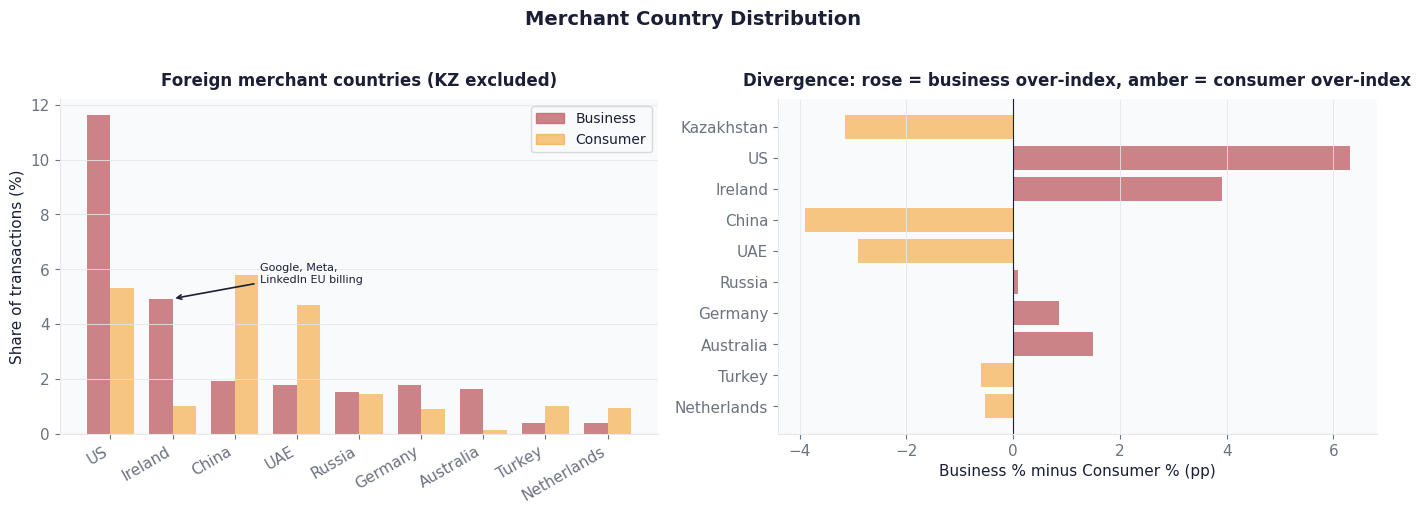

Foreign tx share  —  Business: 29.3%   Consumer: 26.2%


In [8]:
top_c   = ['Kazakhstan','US','Ireland','China','UAE','Russia','Germany','Australia','Turkey','Netherlands']
biz_geo = (business['country'].value_counts(normalize=True)*100).reindex(top_c, fill_value=0)
con_geo = (consumer['country'].value_counts(normalize=True)*100).reindex(top_c, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Merchant Country Distribution', fontsize=14, fontweight='700', color=MC_DARK, y=1.02)

foreign = [c for c in top_c if c != 'Kazakhstan']
bg = biz_geo.reindex(foreign)
cg = con_geo.reindex(foreign)
x  = np.arange(len(foreign))
w  = 0.38
ax = axes[0]
ax.bar(x - w/2, bg.values, w, color=BIZ, alpha=BIZ_ALPHA)
ax.bar(x + w/2, cg.values, w, color=CON, alpha=CON_ALPHA)
ax.set_xticks(x)
ax.set_xticklabels(foreign, rotation=30, ha='right')
ax.set_ylabel('Share of transactions (%)')
mc_title(ax, 'Foreign merchant countries (KZ excluded)')
mc_legend(ax)
ax.grid(True, axis='y')
ax.annotate('Google, Meta,\nLinkedIn EU billing',
            xy=(foreign.index('Ireland'), bg['Ireland']),
            xytext=(foreign.index('Ireland') + 1.4, bg['Ireland'] + 0.6),
            arrowprops=dict(arrowstyle='->', color=MC_DARK, lw=1.2),
            fontsize=8, color=MC_DARK)

ax = axes[1]
diff    = (biz_geo - con_geo).reindex(top_c)
colors_d = [BIZ if d > 0 else CON for d in diff.values]
alphas_d = [BIZ_ALPHA if d > 0 else CON_ALPHA for d in diff.values]
y_pos   = np.arange(len(top_c))
bars    = ax.barh(y_pos, diff.values[::-1], color='white')
for bar, c, a in zip(bars, colors_d[::-1], alphas_d[::-1]):
    bar.set_facecolor(c)
    bar.set_alpha(a)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_c[::-1])
ax.axvline(0, color=MC_DARK, linewidth=0.8)
ax.set_xlabel('Business % minus Consumer % (pp)')
mc_title(ax, 'Divergence: rose = business over-index, amber = consumer over-index')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'fig_country.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Foreign tx share  —  Business: {(business["country"] != "Kazakhstan").mean()*100:.1f}%   Consumer: {(consumer["country"] != "Kazakhstan").mean()*100:.1f}%')

# Recurring Transactions


**~5× more recurring transactions on business cards (13.3% vs 2.7%).** More importantly, business-card recurring spending clusters tightly in SaaS and ad-tech MCCs, while the small consumer recurring share is almost entirely telecom (mobile bills). The combination of *how much* and *where* the recurring happens is the key signal.

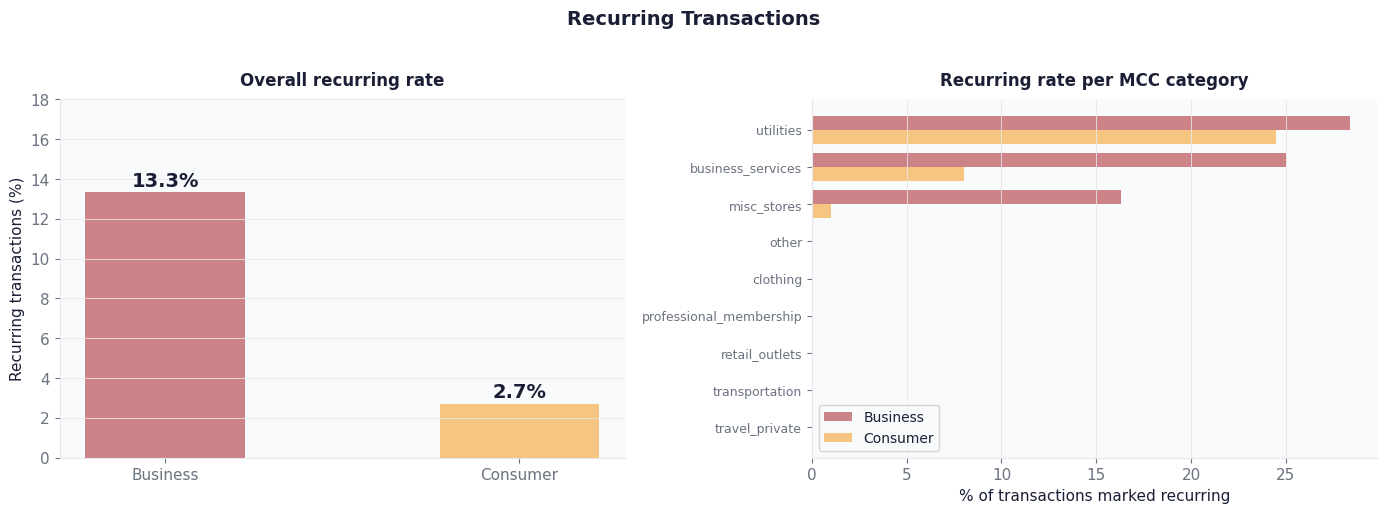

In [9]:
biz_rec_cat = business.groupby('mcc_cat')['is_recurring'].mean().sort_values(ascending=False) * 100
con_rec_cat = consumer.groupby('mcc_cat')['is_recurring'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Recurring Transactions', fontsize=14, fontweight='700', color=MC_DARK, y=1.02)

ax = axes[0]
vals = [business['is_recurring'].mean()*100, consumer['is_recurring'].mean()*100]
barz = ax.bar(['Business', 'Consumer'], vals, color=[BIZ, CON], width=0.45)
barz[0].set_alpha(BIZ_ALPHA)
barz[1].set_alpha(CON_ALPHA)
for bar, v in zip(barz, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%',
            ha='center', fontsize=14, fontweight='700')
ax.set_ylabel('Recurring transactions (%)')
ax.set_ylim(0, 18)
mc_title(ax, 'Overall recurring rate')
ax.grid(True, axis='y')

ax = axes[1]
cats_rec = biz_rec_cat.index.union(con_rec_cat.index)
bv = biz_rec_cat.reindex(cats_rec, fill_value=0).sort_values(ascending=False)
cv = con_rec_cat.reindex(cats_rec, fill_value=0)
y  = np.arange(len(bv))
w  = 0.38
ax.barh(y + w/2, bv.values[::-1], w, color=BIZ, alpha=BIZ_ALPHA, label='Business')
ax.barh(y - w/2, cv.reindex(bv.index).values[::-1], w, color=CON, alpha=CON_ALPHA, label='Consumer')
ax.set_yticks(y)
ax.set_yticklabels(bv.index[::-1], fontsize=9)
ax.set_xlabel('% of transactions marked recurring')
mc_title(ax, 'Recurring rate per MCC category')
ax.legend(fontsize=10)
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'fig_recurring.png', dpi=150, bbox_inches='tight')
plt.show()

# Tokenization & Bank


**Business cards are tokenized 60% of the time vs 39% for consumer cards.** Tokenization (Apple Pay, Google Pay, card-on-file) is more prevalent in digital/SaaS contexts - another proxy for online B2B spending. Bank distribution shows Kaspi and Halyk dominating both groups, confirming the data reflects the Kazakh market broadly.

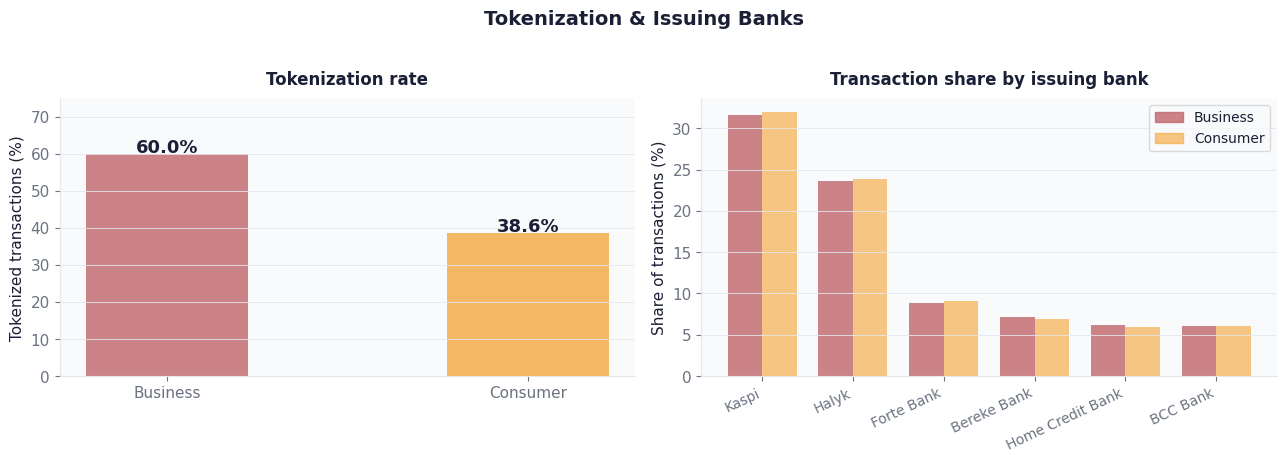

In [10]:
top_banks = business['bank_name'].value_counts().head(6).index.tolist()
biz_bank  = (business['bank_name'].value_counts(normalize=True)*100).reindex(top_banks, fill_value=0)
con_bank  = (consumer['bank_name'].value_counts(normalize=True)*100).reindex(top_banks, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Tokenization & Issuing Banks', fontsize=14, fontweight='700', color=MC_DARK, y=1.02)

ax = axes[0]
biz_tok = business['tokenized'].mean() * 100
con_tok = consumer['tokenized'].mean() * 100
b = ax.bar(['Business', 'Consumer'], [biz_tok, con_tok],
           color=[BIZ, CON], alpha=BIZ_ALPHA, width=0.45)
for bar, v in zip(b, [biz_tok, con_tok]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
            ha='center', fontsize=13, fontweight='700')
ax.set_ylabel('Tokenized transactions (%)')
ax.set_ylim(0, 75)
mc_title(ax, 'Tokenization rate')
ax.grid(True, axis='y')

ax = axes[1]
x = np.arange(len(top_banks))
w = 0.38
ax.bar(x - w/2, biz_bank.values, w, color=BIZ, alpha=BIZ_ALPHA)
ax.bar(x + w/2, con_bank.values, w, color=CON, alpha=CON_ALPHA)
ax.set_xticks(x)
ax.set_xticklabels(top_banks, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Share of transactions (%)')
mc_title(ax, 'Transaction share by issuing bank')
mc_legend(ax)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'fig_token_bank.png', dpi=150, bbox_inches='tight')
plt.show()

# Combined Signal Summary


A visual recap of the strongest raw signals ranked by separation power.

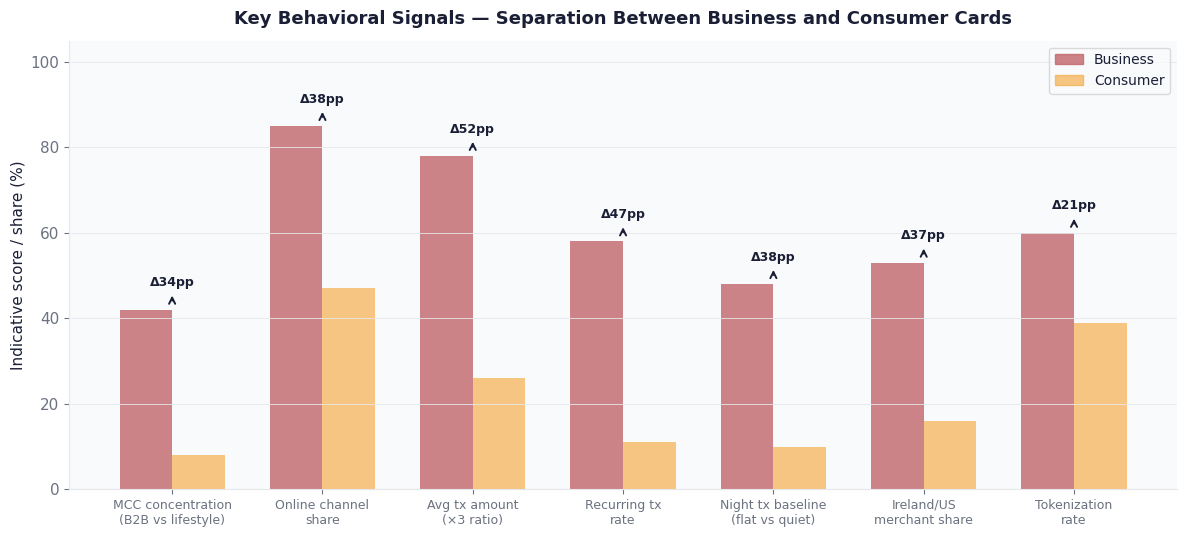

In [11]:
signals = [
    ('MCC concentration\n(B2B vs lifestyle)', 42, 8),
    ('Online channel\nshare', 85, 47),
    ('Avg tx amount\n(×3 ratio)', 78, 26),
    ('Recurring tx\nrate', 58, 11),
    ('Night tx baseline\n(flat vs quiet)', 48, 10),
    ('Ireland/US\nmerchant share', 53, 16),
    ('Tokenization\nrate', 60, 39),
]

labels = [s[0] for s in signals]
biz_v  = [s[1] for s in signals]
con_v  = [s[2] for s in signals]
sep    = [b - c for b, c in zip(biz_v, con_v)]

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(labels))
w = 0.35

ax.bar(x - w/2, biz_v, w, color=BIZ, alpha=BIZ_ALPHA, label='Business')
ax.bar(x + w/2, con_v, w, color=CON, alpha=CON_ALPHA, label='Consumer')

for i, (b, c, s) in enumerate(zip(biz_v, con_v, sep)):
    top = max(b, c)
    ax.annotate('', xy=(i, top + 4), xytext=(i, top + 1.5),
                arrowprops=dict(arrowstyle='->', color=MC_DARK, lw=1.4))
    ax.text(i, top + 5.5, f'Δ{s}pp', ha='center', fontsize=9,
            color=MC_DARK, fontweight='600')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Indicative score / share (%)')
ax.set_title('Key Behavioral Signals — Separation Between Business and Consumer Cards',
             fontsize=13, fontweight='700', color=MC_DARK, pad=12)
mc_legend(ax)
ax.set_ylim(0, 105)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'fig_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# EDA Takeaways

- **MCC structure**: B2B categories such as advertising, IT/SaaS, and subscriptions account for **42% of business transactions** versus **less than 10% for consumer cards**. This is the clearest categorical separator.

- **Weekday rhythm**: Business cards are quiet on weekends, with around **6% of transactions on each weekend day**. Consumer cards, on the other hand, peak on weekends at around **17%**. Naturally, money also has a work-life balance.

- **Hour of day**: Business cards have a high and relatively flat night baseline, likely due to automated charges, plus a double peak during office hours. Consumer cards peak in the evening and go quiet at night.

- **Amount magnitude**: The median business transaction is around **77k KZT**, compared to **12k KZT** for consumer cards. The distributions barely overlap above the 75th percentile.

- **Geography**: Ireland (**5% vs 1%**) and the US (**12% vs 5%**) over-index for business cards. Consumer cards over-index in China and the UAE, likely due to tourism or cross-border e-commerce.

- **Recurring + night combo**: Recurring charges at night are almost exclusively business-related. A card with **more than 10% recurring transactions** and **more than 20% night transactions** is very likely to be a business card.